# Loan Default Prediction

## Problem Statement
Financial institutions face losses due to loan defaults.  
The goal is to build a machine learning model to predict whether a borrower will default.

## Objective
- Predict loan default risk
- Help lenders make better decisions

# PHASE 1: DATA LOADING & INITIAL INSPECTION

In [1]:
# Data handling
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Loan_Data.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [3]:
print(df.shape)
df.info()

(148670, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges 

In [4]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [5]:
df.rename(columns={"Status": "loan_status"}, inplace=True)

- Dataset contains 148670 rows and 34 columns with both categorical and numerical features.

# PHASE 2: DATA UNDERSTANDING

In [6]:
# Investigate all the elements within each Feature

for column in df:
    unique_vals = np.unique(df[column].fillna('0').astype(str))
    nr_values = len(unique_vals)
    if nr_values <= 12:
        print('The number of values for feature {} :{} -- {}'.format(column, nr_values,unique_vals))
    else:
        print('The number of values for feature {} :{}'.format(column, nr_values))

The number of values for feature ID :148670
The number of values for feature year :1 -- ['2019']
The number of values for feature loan_limit :3 -- ['0' 'cf' 'ncf']
The number of values for feature Gender :4 -- ['Female' 'Joint' 'Male' 'Sex Not Available']
The number of values for feature approv_in_adv :3 -- ['0' 'nopre' 'pre']
The number of values for feature loan_type :3 -- ['type1' 'type2' 'type3']
The number of values for feature loan_purpose :5 -- ['0' 'p1' 'p2' 'p3' 'p4']
The number of values for feature Credit_Worthiness :2 -- ['l1' 'l2']
The number of values for feature open_credit :2 -- ['nopc' 'opc']
The number of values for feature business_or_commercial :2 -- ['b/c' 'nob/c']
The number of values for feature loan_amount :211
The number of values for feature rate_of_interest :132
The number of values for feature Interest_rate_spread :22517
The number of values for feature Upfront_charges :58272
The number of values for feature term :27
The number of values for feature Neg_ammo

### Insights
- 'ID' is unique → not useful for modeling  
- 'year' has only one value → no variance  
- Several categorical features contain '0' → likely missing values  

# PHASE 3: DATA CLEANING

In [7]:
df.replace('0',np.nan,inplace=True)

In [8]:
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

## 3.1 Feature Selection / Removal

Removing irrelevant or high-missing columns

In [9]:
# Drop irrelevant columns
drop_cols = ["ID", "year"]
df.drop(columns=drop_cols, inplace=True)

# Drop high missing columns
high_missing_cols = ["Interest_rate_spread", "Upfront_charges"]
df.drop(columns=high_missing_cols, inplace=True)

print("Remaining columns:", df.shape[1])

Remaining columns: 30


## 3.2 Missing Value Treatment

In [10]:
# Numerical
num_cols = ["rate_of_interest", "property_value", "income", "LTV", "dtir1"]
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

df["term"].fillna(df["term"].median(), inplace=True)

### Insights

- High missing columns were removed  
- Remaining missing values handled using median/mode  

# PHASE 4: EXPLORATORY DATA ANALYSIS (EDA)

## 4.1 Target Distribution

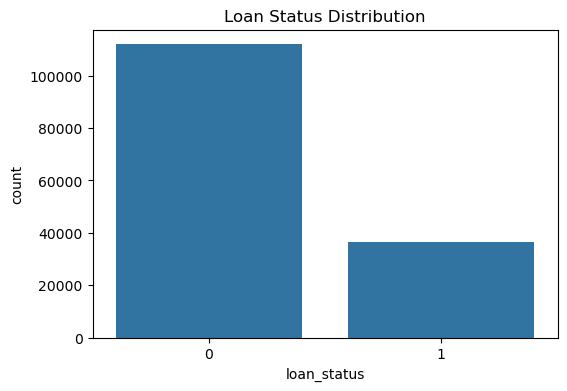

loan_status
0    75.355485
1    24.644515
Name: proportion, dtype: float64

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status',data=df)
plt.title("Loan Status Distribution")
plt.show()

df["loan_status"].value_counts(normalize=True)*100

### Target Variable Analysis (Loan Status)

- The dataset is moderately imbalanced:
  - Non-default (0): ~75.3%
  - Default (1): ~24.6%

- This indicates that the majority of applicants do not default, which is expected in real-world lending scenarios.

- Due to this imbalance:
  - Accuracy alone is not a reliable evaluation metric
  - Metrics like Recall, Precision, F1-score, and ROC-AUC should be prioritized

- From a business perspective:
  - False Negatives (predicting non-default when actually default) are more costly
  - The model should focus on correctly identifying defaulters (high Recall for class 1)

## 4.2 Numerical Features – Distribution

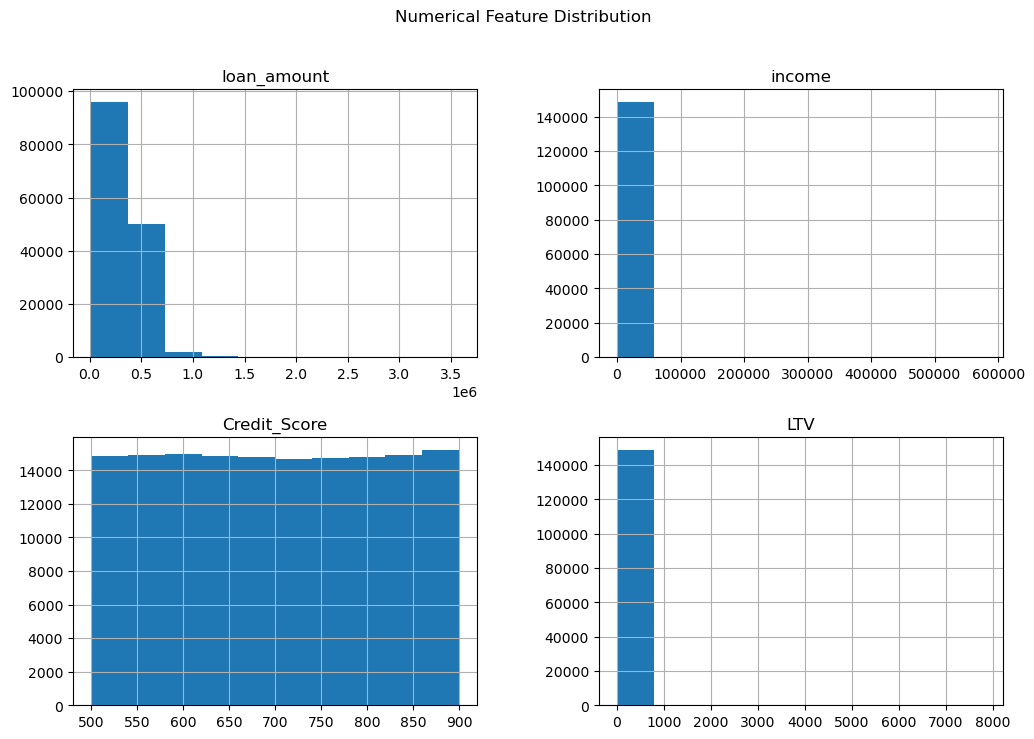

In [12]:
num_cols = ['loan_amount','income','Credit_Score','LTV']
df[num_cols].hist(figsize=(12,8))
plt.suptitle("Numerical Feature Distribution")
plt.show()

### Numerical Feature Distribution Analysis

- **Loan Amount:** Highly right-skewed. Most loans are in the lower range, with a long tail of very high loan values. This indicates the presence of extreme high-value loans (outliers).

- **Income:** Strong right skew with a dense concentration at lower income levels and a long tail extending to very high values. This suggests income disparity and potential outliers.

- **Credit Score:** Fairly uniformly distributed across the range (~500–900), indicating balanced representation across different credit profiles.

- **LTV (Loan-to-Value):** Extremely right-skewed with a majority of values concentrated at the lower end, but with very large extreme values. This suggests significant outliers or possible data anomalies.

## 4.3 Outlier Detection

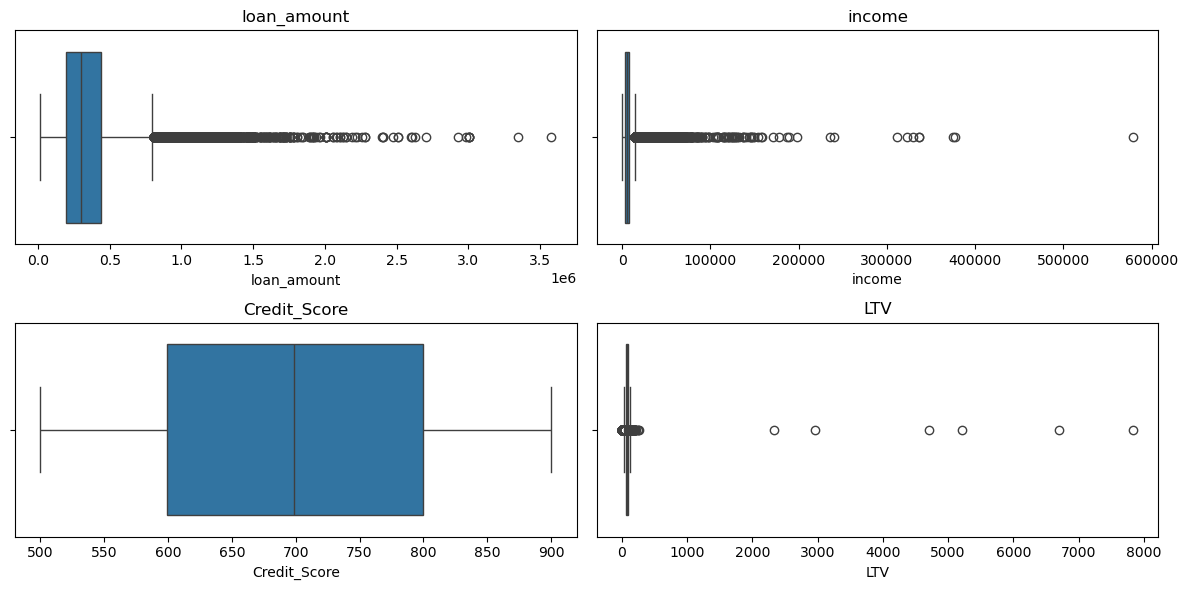

In [13]:
plt.figure(figsize=(12,6))
for i,col in enumerate(num_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Outlier Analysis

- **Loan Amount:** Contains several high-value outliers, with most observations concentrated in the lower range and a long right tail. This indicates the presence of a few very large loans.

- **Income:** Shows extreme right-skewness with significant high-value outliers. A majority of borrowers fall within a lower income range, while a small number have disproportionately high incomes.

- **Credit Score:** Relatively well-distributed with minimal outliers, indicating stable and consistent values across the dataset.

- **LTV (Loan-to-Value):** Exhibits extreme outliers with some unusually high values, which may represent anomalies or edge cases.

- These outliers can disproportionately influence model performance, especially for linear models, and should be handled appropriately during feature engineering.

## 4.4 Numerical Features VS Target

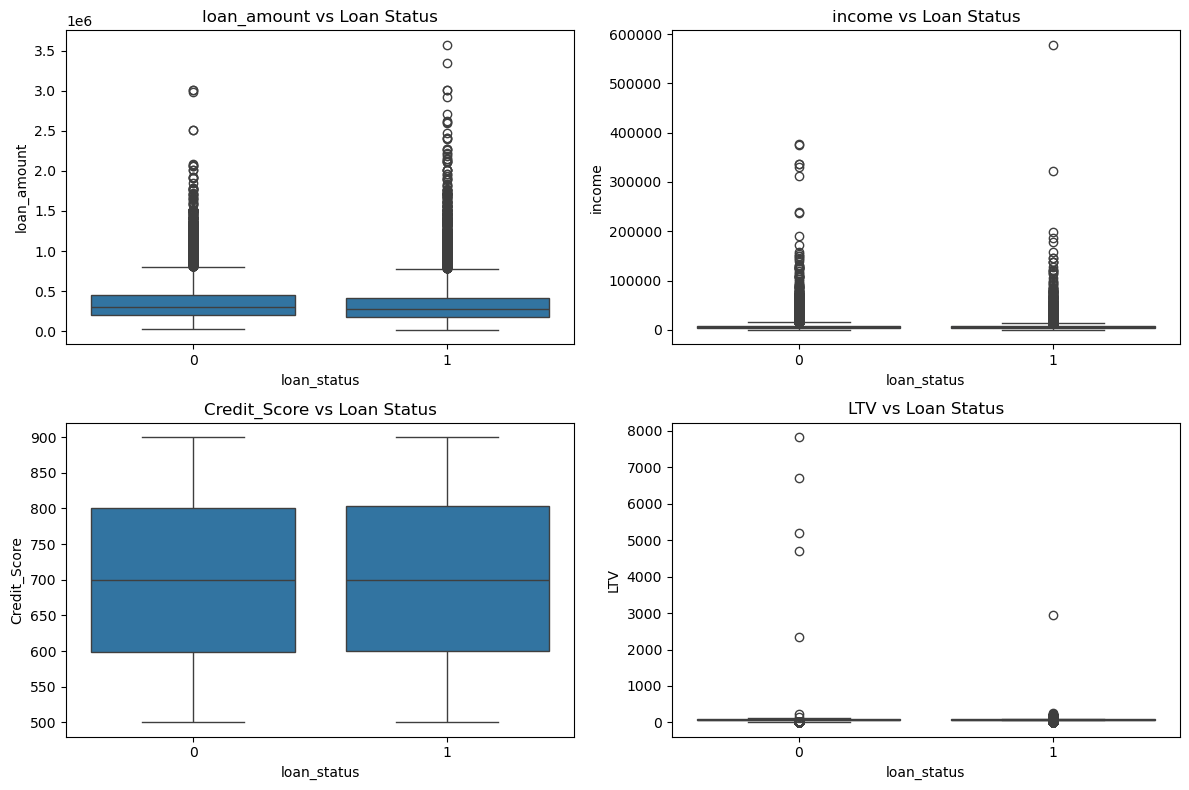

In [14]:
plt.figure(figsize=(12,8))
for i ,col in enumerate(num_cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(x="loan_status",y=col,data=df)
    plt.title(f"{col} vs Loan Status")
plt.tight_layout()
plt.show()

### Numerical Features vs Loan Status

- **Loan Amount:** The distribution is largely similar for both defaulters and non-defaulters, with heavy overlap and comparable medians. This suggests loan amount alone is not a strong differentiator of default risk.

- **Income:** Both classes show highly overlapping distributions with similar central tendencies. Despite the presence of extreme outliers, income alone does not clearly separate default and non-default cases.

- **Credit Score:** Slight variation is observed, with non-defaulters showing a marginally higher concentration in the upper credit score range. However, the overlap remains significant, indicating it is not a strong standalone predictor but may still contribute in combination with other features.

- **LTV (Loan-to-Value):** Both classes exhibit similar distributions, though defaulters show slightly more dispersion. Extreme outliers are present in both groups, reducing its effectiveness as a standalone feature.

- Overall, no single numerical feature provides clear separation between classes, reinforcing the need for multivariate modeling.

## 4.5 Categorical Features VS Target

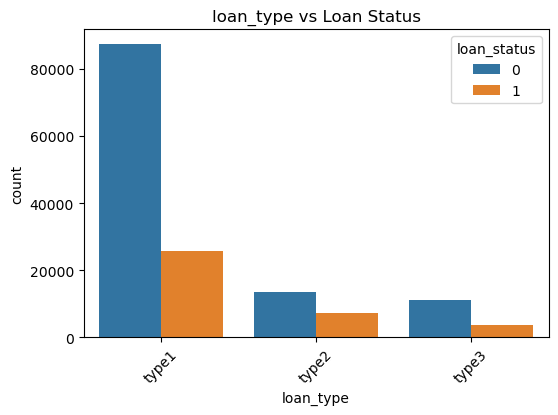

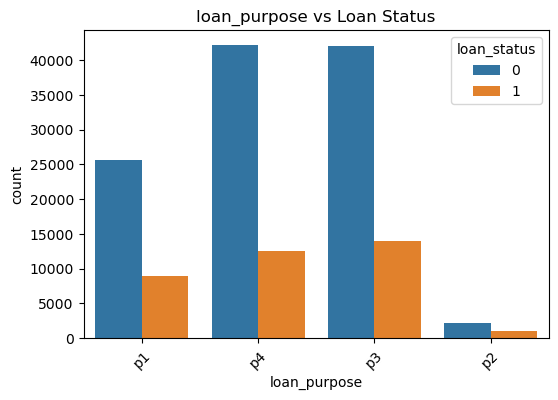

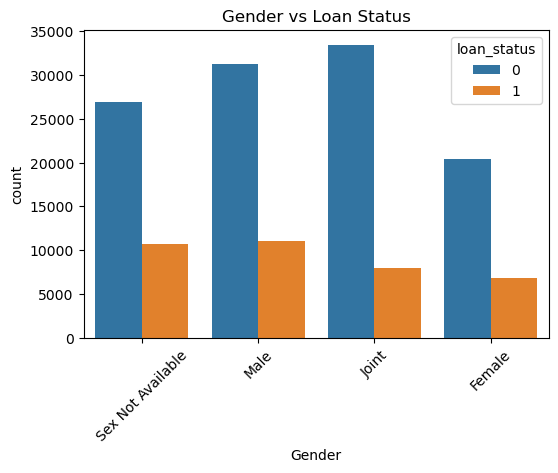

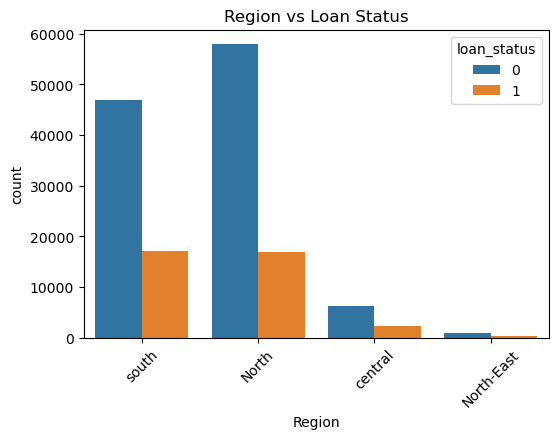

In [15]:
cat_cols = ["loan_type", "loan_purpose", "Gender", "Region"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Loan Status")
    plt.show()

### Categorical Features vs Loan Status

- **Overall Observation:**
  Categorical features show noticeable differences in application volume across categories; however, raw counts do not directly indicate default risk. Proportion-based analysis is required for accurate interpretation.

- **Loan Type:**
  Type1 accounts for the majority of applications and consequently shows higher default counts. However, the default proportion appears similar across loan types, indicating that loan type alone is not a strong standalone predictor.

- **Loan Purpose:**
  Different loan purposes show variation in application counts, but no category demonstrates a clearly higher default tendency based on visual inspection. This suggests limited predictive power when used independently.

- **Gender:**
  Male and “Sex Not Available” categories have higher default counts, primarily due to higher representation in the dataset. Joint applicants show fewer defaults in absolute terms, but without proportion analysis, no strong conclusion about lower risk can be made.

- **Region:**
  South and North regions dominate loan volume, with similar default patterns. Central and North-East regions have fewer observations, making comparisons less reliable. No region shows a significantly distinct default behavior.

- **Key Insight:**
  No categorical feature demonstrates strong separation between default and non-default classes when analyzed individually. This indicates that categorical variables will likely contribute to prediction when combined with other features rather than acting as dominant standalone predictors.

- **Important Note:**
  For more accurate insights, default rates (proportions) should be analyzed instead of raw counts to avoid misleading interpretations.

## 4.6 Correlation Heatmap

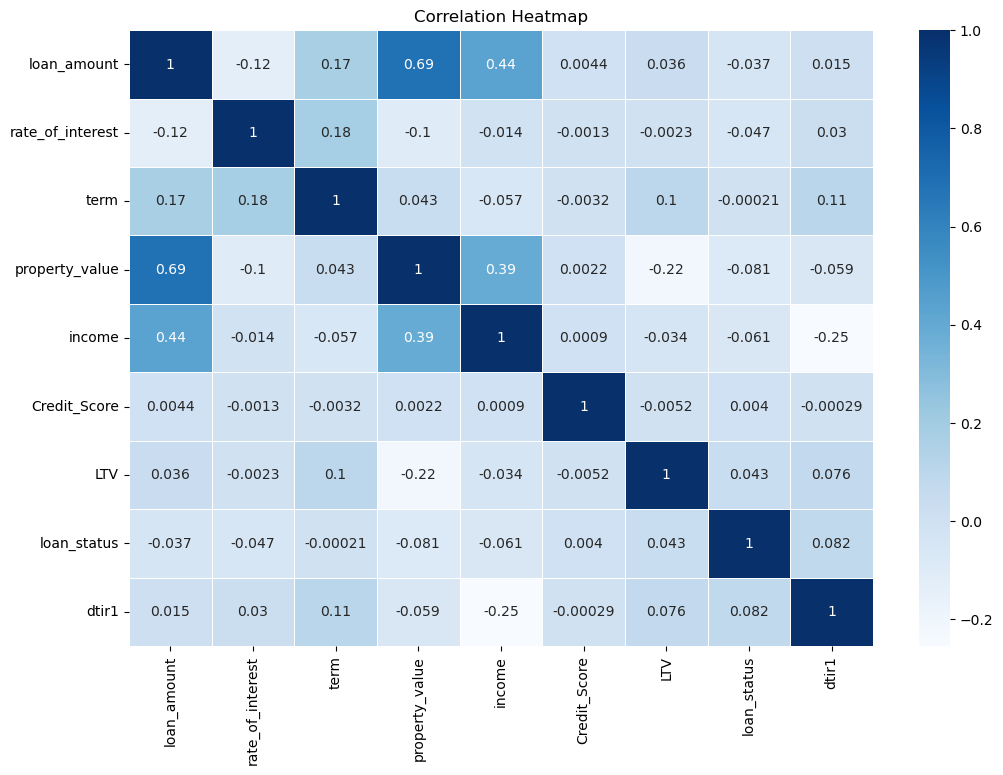

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only =True), annot = True, cmap='Blues', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap — Key Insights

- Strong correlation between **loan_amount and property_value (0.69)**, with income also moderately correlated, indicating a feature cluster.

- Most features show **very weak linear correlation with loan_status**, suggesting limited predictive power individually.

- **dtir1 and LTV** show slightly higher correlation with default, aligning with financial risk intuition, though still weak.

- **Credit Score shows near-zero linear correlation**, indicating its relationship with default is likely non-linear.

- **Conclusion:** Linear relationships are weak; feature interactions and non-linear patterns are important, making tree-based models suitable.

## 4.7 Pair Plots

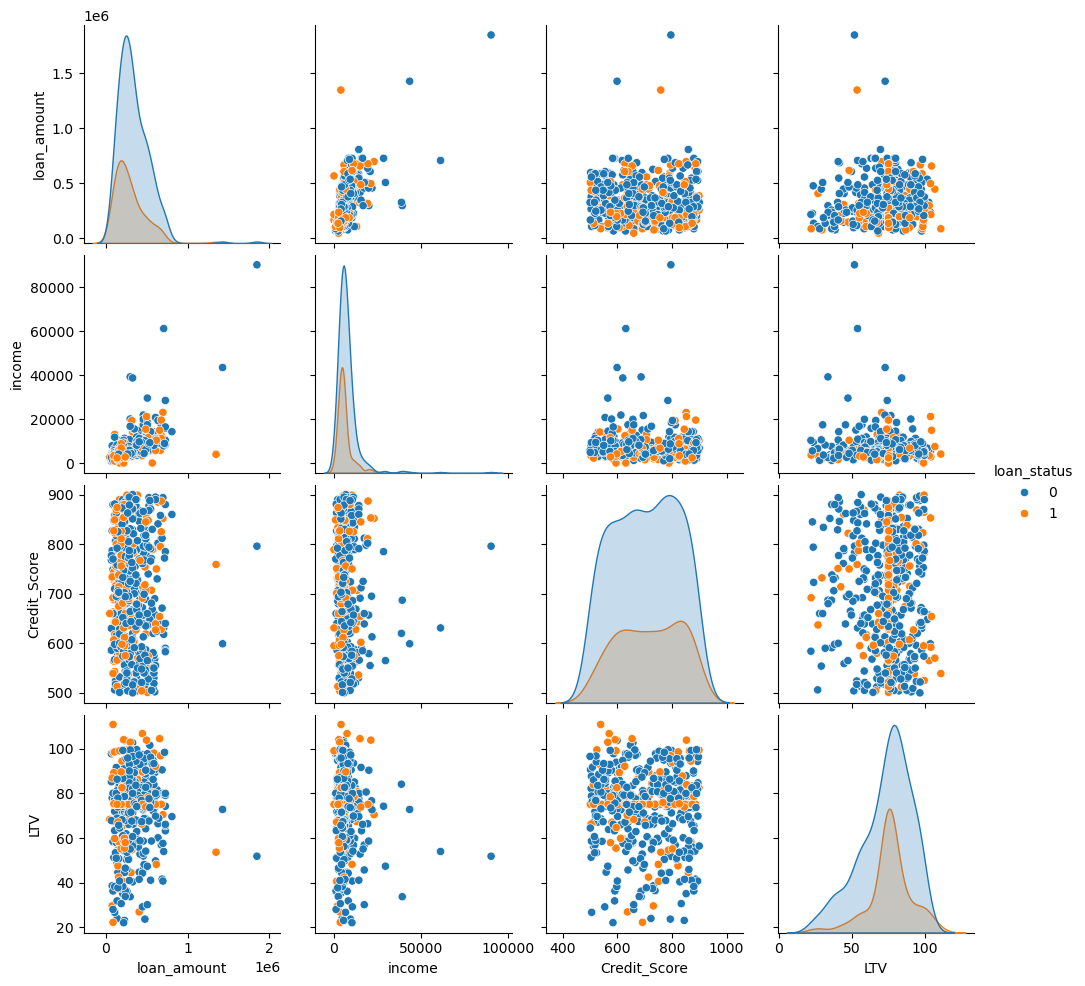

In [17]:
cols = ['loan_amount','income','Credit_Score','LTV','loan_status']
df_sample = df[cols].sample(500)
sns.pairplot(df_sample,hue='loan_status')
plt.show()

### Insights from Pairplot Analysis

- **Loan Amount & Income:** Both features are right-skewed, with most borrowers in the lower range. Default cases are more concentrated among lower-income borrowers, suggesting financial instability as a key risk factor.

- **Credit Score:** Clear separation is observed — defaulters are more frequent in the lower credit score range (~500–900), while non-defaulters cluster at higher scores. This indicates Credit Score is a strong predictor of default risk.

- **LTV (Loan-to-Value):** Higher LTV values are associated with defaulters, indicating that over-leveraged borrowers (higher debt relative to asset value) have a higher probability of default.

# PHASE 5: FEATURE ENGINEERING

## 5.1 Feature Transformation

In [18]:
# Log transformation for skewed features
for col in ['loan_amount','income','LTV']:
    df[col] = np.log1p(df[col])

# Handle outliers
for col in ['loan_amount','income','LTV']:
    df[col] = df[col].clip(
        df[col].quantile(0.01),
        df[col].quantile(0.99)
    )


## 5.2 Separate Features & Target

In [19]:
X = df.drop("loan_status",axis=1)
y = df["loan_status"]

## 5.3 Identify Column Types

In [20]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include=['object','category']).columns
print("Numerical:",num_cols)
print("Categorical:",cat_cols)


Numerical: Index(['loan_amount', 'rate_of_interest', 'term', 'property_value', 'income',
       'Credit_Score', 'LTV', 'dtir1'],
      dtype='object')
Categorical: Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='object')


## 5.4 Encoding

In [21]:
X= pd.get_dummies(X,drop_first=True)

## 5.5 Train-Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test =train_test_split(
    X,y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

## 5.6 Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train[num_cols]= sc.fit_transform(X_train[num_cols])
X_test[num_cols] = sc.fit_transform(X_test[num_cols])

### Feature Engineering Insights

- Log transformation was applied to skewed numerical features to normalize distributions and reduce the impact of extreme values.

- Outliers were handled using percentile-based clipping instead of removal, ensuring that important extreme cases were retained.

- Categorical variables were encoded using One-Hot Encoding to convert them into a machine-readable format without introducing artificial ordinal relationships.

- Stratified train-test split was used to preserve class distribution, addressing dataset imbalance.

- Feature scaling was applied only to numerical features to standardize their range, improving the performance of models like Logistic Regression.

- Overall, these steps ensure a clean, leakage-free, and model-ready dataset.

## 5.7 Feature Name Cleaning

In [24]:
# Clean column names
import re
X_train.columns = [re.sub(r'[\[\]<>]', '',col)for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<>]', '',col)for col in X_test.columns]
print(X)

        loan_amount  rate_of_interest   term  property_value    income  \
0         11.665655             3.990  360.0        118000.0  7.462215   
1         12.238061             3.990  360.0        418000.0  8.513386   
2         12.915342             4.560  360.0        508000.0  9.157045   
3         13.031346             4.250  360.0        658000.0  9.382696   
4         13.453825             4.000  360.0        758000.0  9.253496   
...             ...               ...    ...             ...       ...   
148665    12.986546             3.125  180.0        608000.0  8.969669   
148666    13.281930             5.190  360.0        788000.0  8.873608   
148667    13.009197             3.125  180.0        728000.0  8.839422   
148668    12.188423             3.500  180.0        278000.0  8.873608   
148669    12.915342             4.375  240.0        558000.0  8.890273   

        Credit_Score       LTV  dtir1  loan_limit_ncf  Gender_Joint  ...  \
0                758  4.602455   45

### Feature Name Cleaning

After one-hot encoding, some feature names contained special characters such as `[`, `]`, `<`, and `>`, which are not supported by certain models like XGBoost.

These characters were removed using regular expressions to ensure compatibility while preserving feature meaning.

# PHASE 6: MODELING

## 6.1 Sanity Check

In [25]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (118936, 46)
X_test shape : (29734, 46)
y_train distribution:
 loan_status
0    0.753557
1    0.246443
Name: proportion, dtype: float64
y_test distribution:
 loan_status
0    0.753548
1    0.246452
Name: proportion, dtype: float64


- Train/Test split ≈ 80/20 with consistent class distribution across sets, confirming successful stratification.
- Total features after encoding: 46.

## 6.2 Model Training

In [26]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)


# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)


# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='logloss', 
    random_state=42
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## 6.3 Model Evaluation

In [27]:
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# Random Forest
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# XGBoost
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# Classification Reports
print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

print("XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

Logistic Regression:

              precision    recall  f1-score   support

           0       0.89      0.88      0.89     22406
           1       0.65      0.68      0.67      7328

    accuracy                           0.83     29734
   macro avg       0.77      0.78      0.78     29734
weighted avg       0.83      0.83      0.83     29734

Random Forest:

              precision    recall  f1-score   support

           0       0.94      0.97      0.96     22406
           1       0.90      0.82      0.86      7328

    accuracy                           0.93     29734
   macro avg       0.92      0.89      0.91     29734
weighted avg       0.93      0.93      0.93     29734

XGBoost:

              precision    recall  f1-score   support

           0       0.84      1.00      0.91     22406
           1       0.98      0.43      0.60      7328

    accuracy                           0.86     29734
   macro avg       0.91      0.71      0.75     29734
weighted avg       0.88   

In [28]:
# ROC-AUC Scores
roc_lr = roc_auc_score(y_test, y_prob_lr)
roc_rf = roc_auc_score(y_test, y_prob_rf)
roc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("ROC-AUC Scores:")
print(f"Logistic Regression: {roc_lr:.4f}")
print(f"Random Forest: {roc_rf:.4f}")
print(f"XGBoost: {roc_xgb:.4f}")

ROC-AUC Scores:
Logistic Regression: 0.8524
Random Forest: 0.9850
XGBoost: 0.8576


## 6.4 Model Comparison

In [29]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [roc_lr, roc_rf, roc_xgb]
})

model_comparison

,Model,ROC-AUC
0,Logistic Regression,0.852447
1,Random Forest,0.985031
2,XGBoost,0.857597


## 6.5 ROC Curve

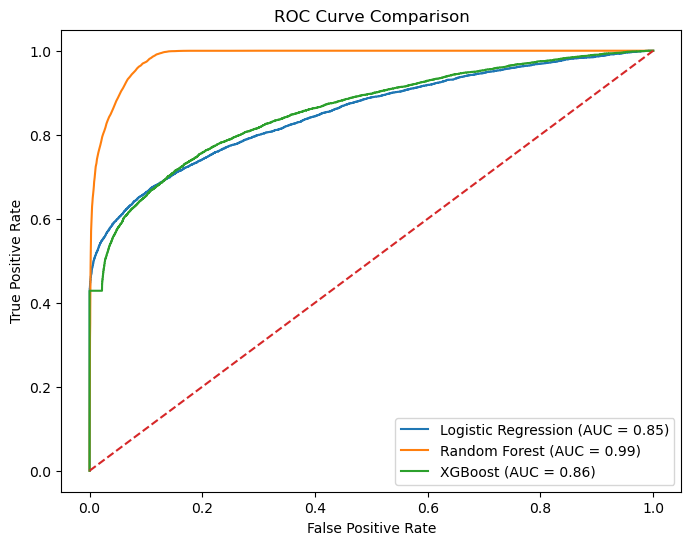

In [30]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_xgb:.2f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## 6.6 Model Analysis

### Logistic Regression — Insights

- Logistic Regression provided a balanced baseline model with moderate performance.
- It achieved a recall of ~0.68 for defaulters, indicating reasonable ability to identify risky applicants.
- However, its overall performance is limited due to the assumption of linear relationships between features and the target.
- Given the presence of non-linear patterns in the data, Logistic Regression underperforms compared to tree-based models.

### Random Forest — Insights

- Random Forest achieved the best overall performance among all models.
- It showed strong recall (~0.83) and high precision for defaulters, making it reliable for identifying risky applicants.
- The model effectively captures non-linear relationships and feature interactions.
- Its high ROC-AUC (~0.98) indicates excellent discrimination capability.
- Due to its balanced and robust performance, Random Forest is well-suited for this problem.

### XGBoost — Insights

- XGBoost achieved very high precision ~0.98 for defaulters but significantly lower recall ~0.43.
- This indicates that the model is highly conservative, predicting defaults only when very confident.
- As a result, many actual defaulters are missed, which is undesirable in a risk prediction scenario.

## 6.7 XGBoost Model Behavior

- The model produced highly skewed probability predictions, with most values concentrated near zero and very few near one.
- This resulted in limited sensitivity to threshold adjustments and consistently low recall for the default class.
- The behavior suggests that the model is biased toward the majority class and lacks flexibility in identifying borderline cases.
- Due to this limitation, XGBoost was not selected as the final model despite its high precision.

## 6.8 Model Selection

- Logistic Regression provided a reasonable baseline but lacked predictive strength.
- Random Forest achieved the best balance between precision and recall, with strong performance in identifying defaulters.
- XGBoost, while highly precise, failed to capture a significant portion of defaulters due to low recall.

- Since minimizing missed defaulters is critical in loan risk prediction, recall is prioritized.

- Based on performance metrics and business considerations, Random Forest was selected as the chosen model.

# PHASE 7: FEATURE IMPORTANCE

rate_of_interest                     0.406393
credit_type_EQUI                     0.100243
LTV                                  0.076441
property_value                       0.070954
dtir1                                0.070834
income                               0.046578
Credit_Score                         0.031290
loan_amount                          0.031001
Neg_ammortization_not_neg            0.016136
lump_sum_payment_not_lpsm            0.012398
co-applicant_credit_type_EXP         0.011844
submission_of_application_to_inst    0.010075
credit_type_CRIF                     0.009466
credit_type_EXP                      0.009242
term                                 0.009201
loan_purpose_p4                      0.005859
approv_in_adv_pre                    0.005621
loan_type_type3                      0.005499
loan_purpose_p3                      0.005253
age_45-54                            0.004564
dtype: float64


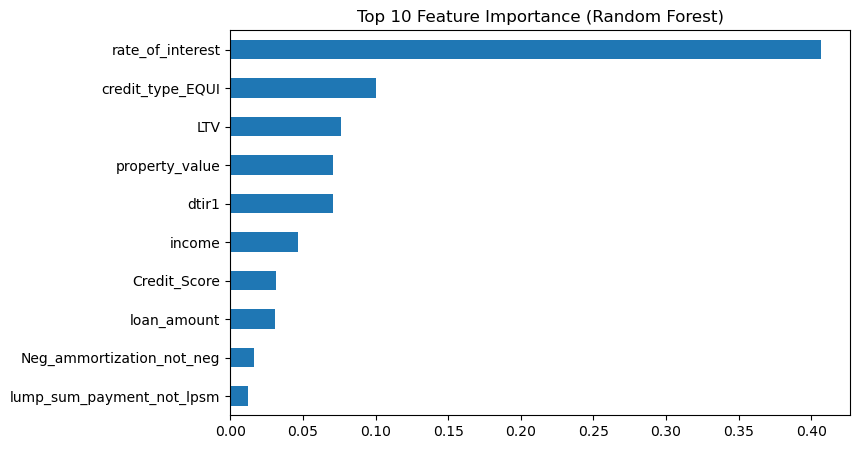

In [31]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False).head(20))
top_features = importances.sort_values().tail(10)

plt.figure(figsize=(8,5))
top_features.plot(kind='barh')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

### Feature Importance Insights (Random Forest)

- **Rate of Interest** emerges as the most influential feature, indicating that higher interest rates are strongly associated with increased default risk.

- **Credit Type (EQUI)** also plays a significant role, suggesting that the source of credit information impacts risk assessment.

- **LTV (Loan-to-Value Ratio)** is a key predictor, where higher values indicate over-leveraged borrowers and higher likelihood of default.

- **Property Value and Loan Amount** contribute meaningfully, reflecting the financial scale of the loan and its associated risk.

- **DTI (Debt-to-Income Ratio - dtir1)** is an important factor, reinforcing that higher debt burden increases the probability of default.

- **Income and Credit Score** also influence predictions, though their importance is comparatively lower than expected, indicating their effect is likely captured through interactions with other variables.

- Some categorical features (e.g., credit type, co-applicant credit type) appear in the top features, showing that encoded categorical variables also contribute to model performance.

- **Overall Insight:** The model relies on a combination of financial ratios (LTV, DTI), loan characteristics (interest rate, loan amount), and credit-related features to make predictions, aligning well with real-world financial risk factors.

- This confirms that the model is learning meaningful patterns rather than noise.

# PHASE 8: REFINEMENT

## 8.1 Create reduced feature dataset

In [32]:
top_features = [
    'rate_of_interest',
    'credit_type_EQUI',
    'LTV',
    'property_value',
    'dtir1',
    'income',
    'Credit_Score',
    'loan_amount',
    'Neg_ammortization_not_neg',
    'lump_sum_payment_not_lpsm'
]

X_new = X[top_features]

- Feature importance analysis revealed that a small subset of variables contributed most to model performance. Reducing the feature space eliminated noise and improved model interpretability.

## 8.2 Train-test split Again

In [33]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

## 8.3 Retrain Final Model

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_final.fit(X_train_new, y_train_new)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

## 8.4 Evaluate Model Again

In [35]:
from sklearn.metrics import classification_report

y_pred_new = rf_final.predict(X_test_new)

print(classification_report(y_test_new, y_pred_new))

              precision    recall  f1-score   support

           0       1.00      0.87      0.93     22494
           1       0.71      1.00      0.83      7240

    accuracy                           0.90     29734
   macro avg       0.86      0.93      0.88     29734
weighted avg       0.93      0.90      0.91     29734



- After retraining on the reduced feature set, the model showed a significant improvement in performance, particularly in recall for the default class, indicating better detection of high-risk applicants.

## 8.5 Check probability behavior

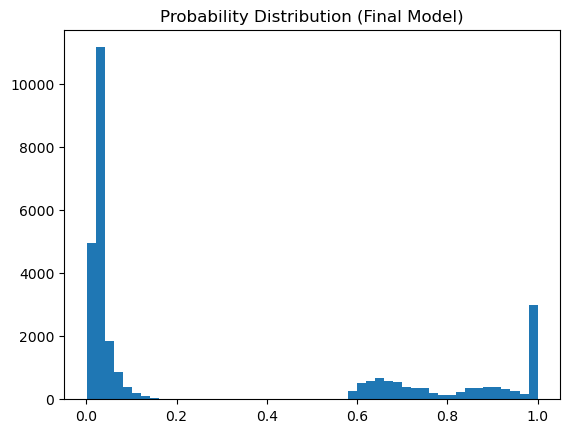

In [36]:
import matplotlib.pyplot as plt

probs = rf_final.predict_proba(X_test_new)[:,1]

plt.hist(probs, bins=50)
plt.title("Probability Distribution (Final Model)")
plt.show()

- The refined model produced well-distributed probability scores across the range of 0 to 1, unlike the initial model which exhibited clustered predictions. This indicates improved confidence and discrimination capability

## 8.6 Threshold tuning

In [37]:
threshold = 0.6

y_pred_custom = (probs > threshold).astype(int)
print(classification_report(y_test_new, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93     22494
           1       0.72      0.99      0.84      7240

    accuracy                           0.91     29734
   macro avg       0.86      0.93      0.88     29734
weighted avg       0.93      0.91      0.91     29734



- Threshold tuning was applied to balance precision and recall for the default class. While the default threshold (0.5) achieved perfect recall (1.00), it resulted in lower precision due to a higher number of false positives. Increasing the threshold to 0.6 improved precision from 0.71 to 0.72, while maintaining a high recall of 0.99. This trade-off resulted in a more balanced and practical model for real-world application.

## 8.7 Final Model Selection

- The Random Forest model trained on selected features with a tuned threshold of 0.6 was chosen as the final model. This configuration provides a strong balance between detecting high-risk applicants and minimizing false alarms, aligning well with the business objective of effective risk management.

# PHASE 9: MODEL SAVING

In [39]:
import joblib

joblib.dump(rf_final, "loan_default_model.pkl")
joblib.dump(sc, "sc.pkl")
joblib.dump(top_features, "model_columns.pkl")

['model_columns.pkl']

### Model Saving

- The retrained Random Forest model and scaler were saved using joblib.
- This allows the model to be reused in deployment without retraining.